**Shopify Stock Visualization, Time-Series Analysis & Financial Insights**


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
df = pd.read_excel("/content/drive/MyDrive/AAPL.xlsx")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"],utc=True)
df['Date'].dtype


datetime64[ns, UTC]

In [ ]:
df = df.sort_values("Date")


In [ ]:
df["Date"] = pd.to_datetime(df["Date"],utc=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29 00:00:00+00:00,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06 00:00:00+00:00,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13 00:00:00+00:00,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20 00:00:00+00:00,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27 00:00:00+00:00,104.849998,108.040001,104.699997,108.000000,101.380676,220230600
...,...,...,...,...,...,...,...
179,2018-03-05 00:00:00+00:00,175.210007,180.000000,174.270004,179.979996,179.979996,139852700
180,2018-03-12 00:00:00+00:00,180.289993,183.500000,177.619995,178.020004,178.020004,155417500
181,2018-03-19 00:00:00+00:00,177.320007,177.470001,164.940002,164.940002,164.940002,172670700
182,2018-03-26 00:00:00+00:00,168.070007,175.149994,165.190002,167.779999,167.779999,157898400


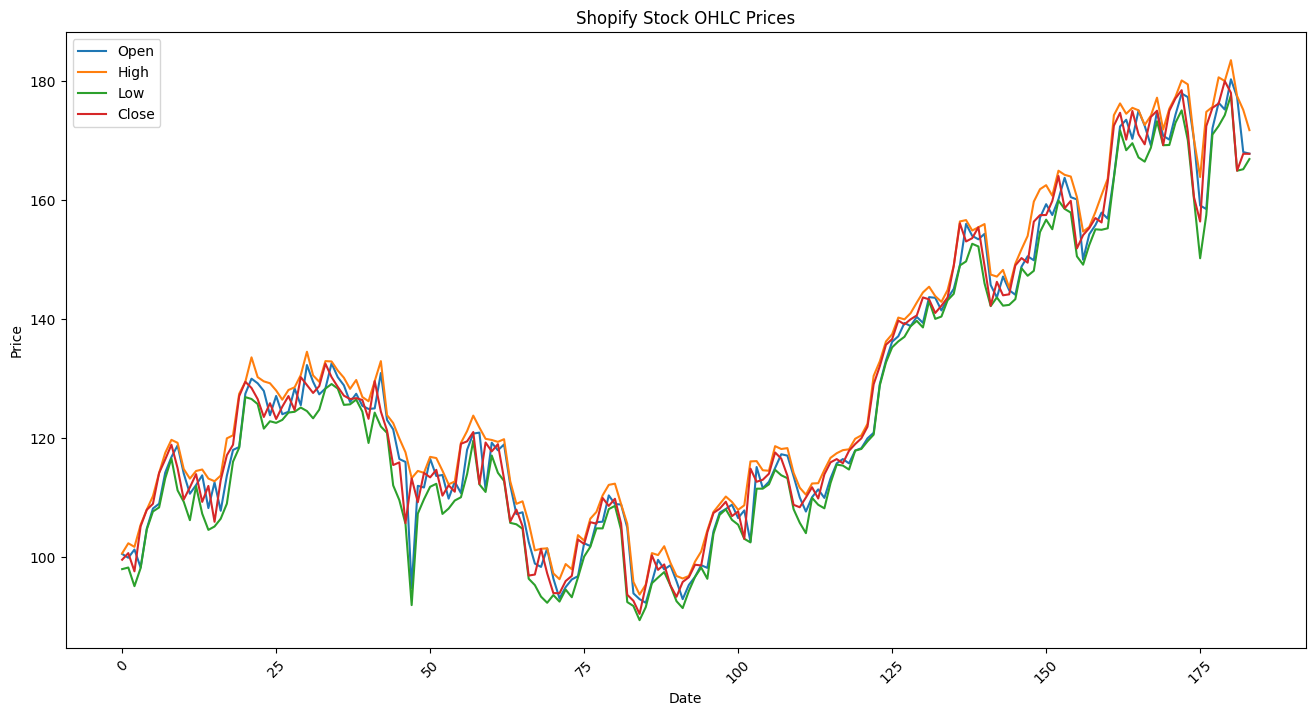

In [ ]:
#OHLC
plt.figure(figsize=(16, 8))

plt.plot(df.index, df["Open"], label="Open")
plt.plot(df.index, df["High"], label="High")
plt.plot(df.index, df["Low"], label="Low")
plt.plot(df.index, df["Close"], label="Close")

plt.title("Shopify Stock OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

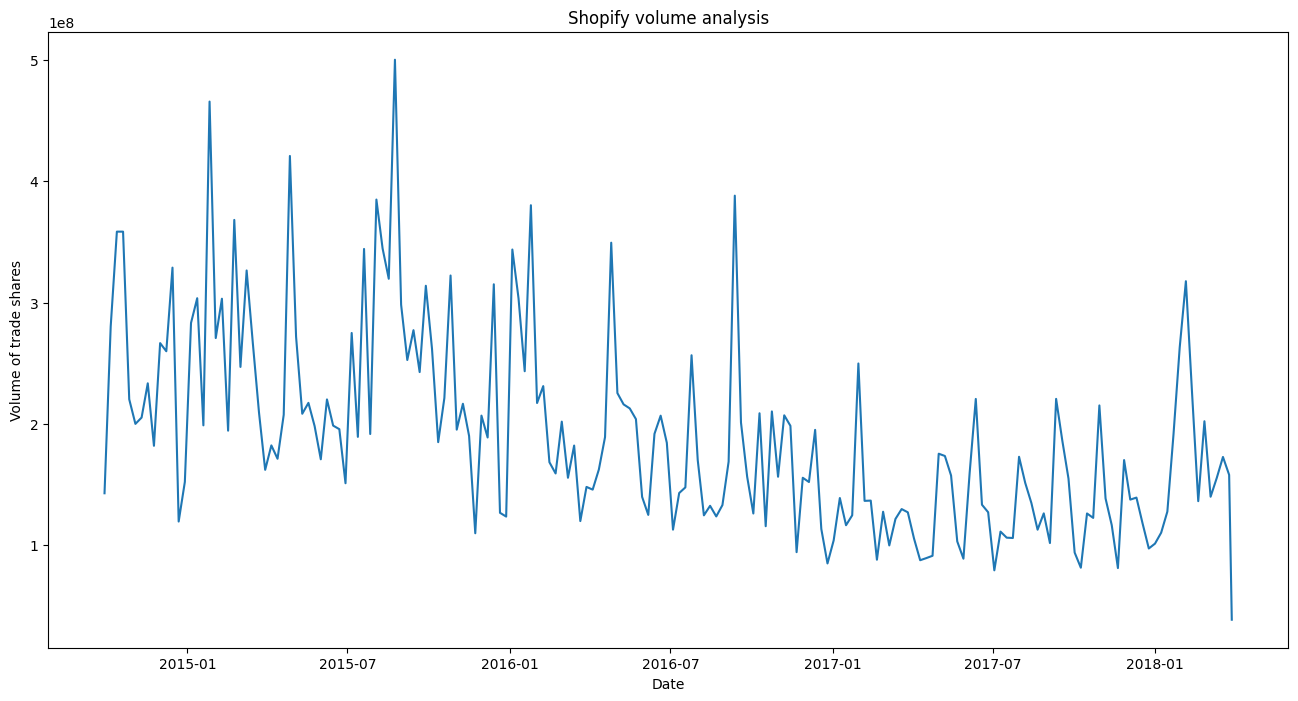

In [ ]:
plt.figure(figsize=(16,8))

plt.plot(df["Date"],df["Volume"])
plt.title("Shopify volume analysis")
plt.xlabel("Date")
plt.ylabel("Volume of trade shares")
plt.show()

In [ ]:

df["MA20"] = df["Close"].rolling(window=20).mean()

df["MA50"] = df["Close"].rolling(window=50).mean()

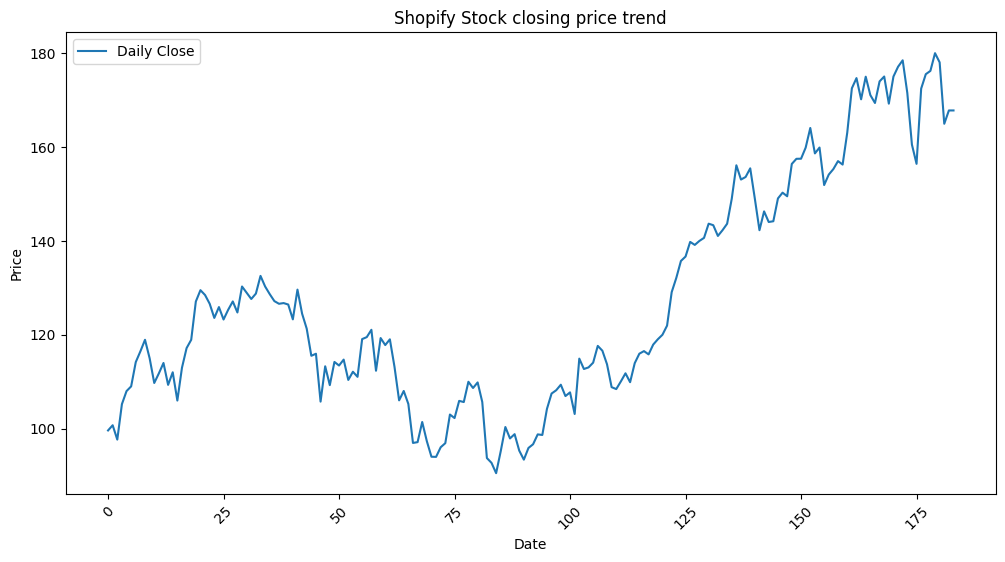

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"], label="Daily Close")
plt.title("Shopify Stock closing price trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

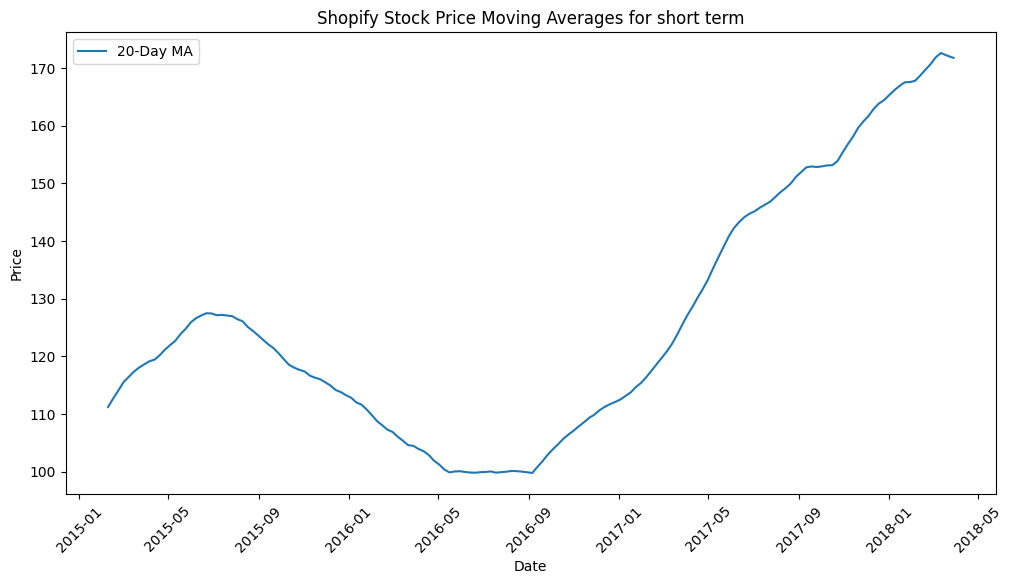

In [ ]:
#Moving Average
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df["MA20"], label="20-Day MA")

plt.title("Shopify Stock Price Moving Averages for short term")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

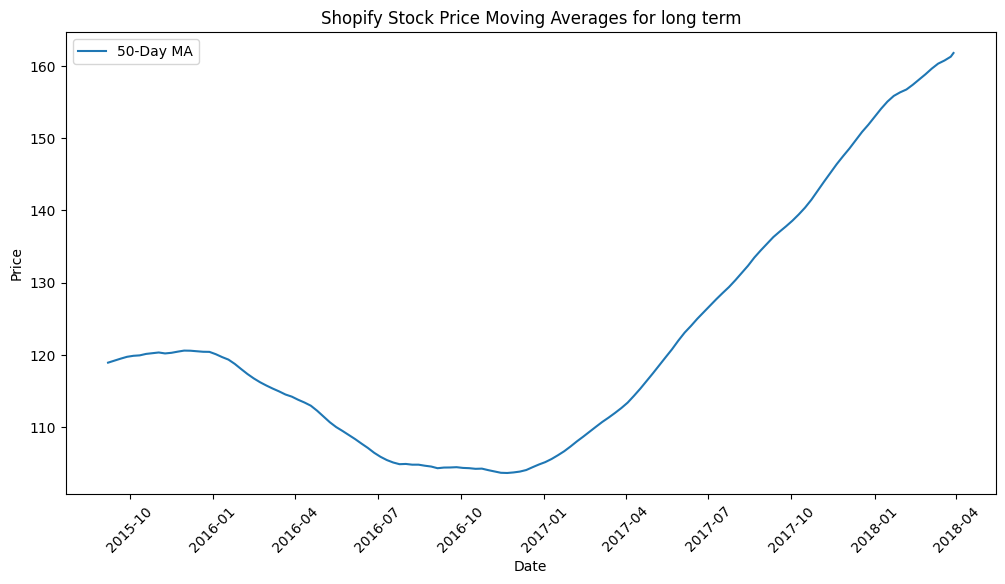

In [ ]:
#Moving Average
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df["MA50"], label="50-Day MA")

plt.title("Shopify Stock Price Moving Averages for long term")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

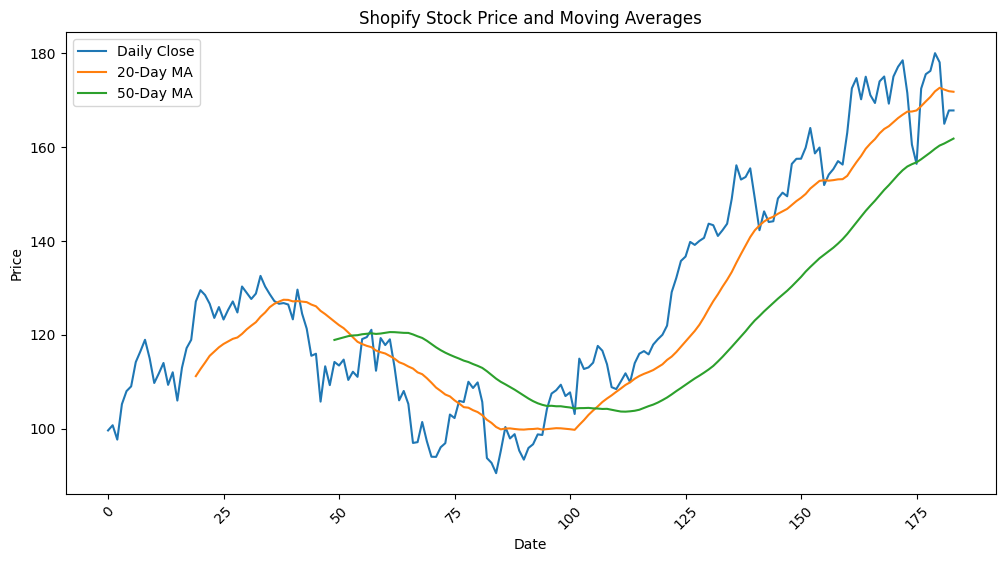

In [ ]:
#Moving Average
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"], label="Daily Close")
plt.plot(df.index, df["MA20"], label="20-Day MA")
plt.plot(df.index, df["MA50"], label="50-Day MA")

plt.title("Shopify Stock Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Daily return
df["Daily_Return"] = df["Close"].pct_change()


df

,Date,Open,High,Low,Close,Adj Close,Volume,MA20,MA50,Daily_Return
0,2014-09-29 00:00:00+00:00,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,NaN,NaN,NaN
1,2014-10-06 00:00:00+00:00,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,NaN,NaN,0.011142
2,2014-10-13 00:00:00+00:00,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,NaN,NaN,-0.030378
3,2014-10-20 00:00:00+00:00,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,NaN,NaN,0.077301
4,2014-10-27 00:00:00+00:00,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,NaN,NaN,0.026421
...,...,...,...,...,...,...,...,...,...,...
179,2018-03-05 00:00:00+00:00,175.210007,180.000000,174.270004,179.979996,179.979996,139852700,171.852999,159.6218,0.021395
180,2018-03-12 00:00:00+00:00,180.289993,183.500000,177.619995,178.020004,178.020004,155417500,172.601499,160.3090,-0.010890
181,2018-03-19 00:00:00+00:00,177.320007,177.470001,164.940002,164.940002,164.940002,172670700,172.223499,160.7410,-0.073475
182,2018-03-26 00:00:00+00:00,168.070007,175.149994,165.190002,167.779999,167.779999,157898400,171.878999,161.2756,0.017218


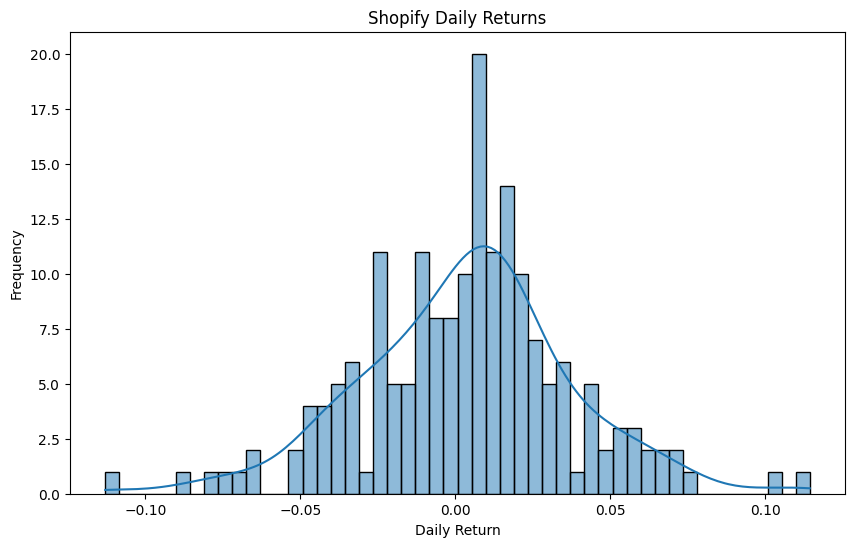

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Shopify Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Rolling Volatility
df["Rolling_Volatility_20"] = (
    df["Daily_Return"]
    .rolling(window=20)
    .std()
)
df["Rolling_Volatility_20"].dropna()

,Rolling_Volatility_20
20,0.037803
21,0.038118
22,0.037325
23,0.035034
24,0.034870
...,...
179,0.037749
180,0.036989
181,0.038728
182,0.038830


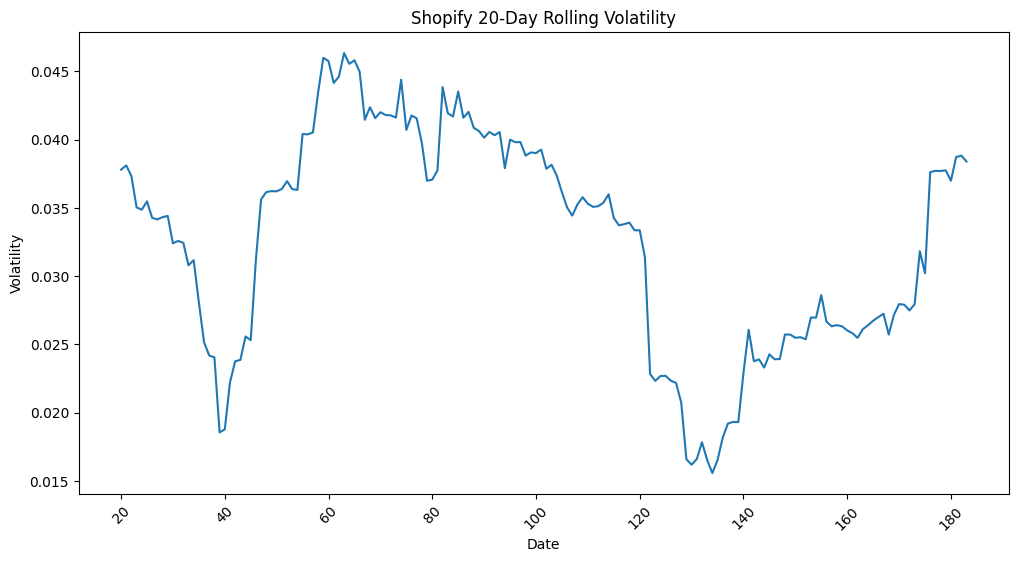

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["Rolling_Volatility_20"]
)

plt.title("Shopify 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()

**Financial Summary Report**

In [ ]:


mean_return = df["Daily_Return"].mean()
std_return = df["Daily_Return"].std()
max_return = df["Daily_Return"].max()
min_return = df["Daily_Return"].min()

print("Financial Summary Report")
print("------------------------")
print("Average Daily Return:", round(mean_return, 4))
print("Return Standard Deviation:", round(std_return, 4))
print("Highest Daily Return:", round(max_return, 4))
print("Lowest Daily Return:", round(min_return, 4))

print("\nStock Stability:")
if std_return < 0.02:
    print("The stock shows relatively stable returns.")
else:
    print("The stock shows higher return variability.")

print("\nHigh-Volatility Periods:")
high_volatility = df[df["Rolling_Volatility_20"] > df["Rolling_Volatility_20"].quantile(0.90)]

print(high_volatility[["Date", "Rolling_Volatility_20"]])

Financial Summary Report
------------------------
Average Daily Return: 0.0034
Return Standard Deviation: 0.034
Highest Daily Return: 0.1143
Lowest Daily Return: -0.113

Stock Stability:
The stock shows higher return variability.

High-Volatility Periods:
                        Date  Rolling_Volatility_20
58 2015-11-09 00:00:00+00:00               0.043477
59 2015-11-16 00:00:00+00:00               0.045997
60 2015-11-23 00:00:00+00:00               0.045751
61 2015-11-30 00:00:00+00:00               0.044155
62 2015-12-07 00:00:00+00:00               0.044621
63 2015-12-14 00:00:00+00:00               0.046343
64 2015-12-21 00:00:00+00:00               0.045552
65 2015-12-28 00:00:00+00:00               0.045818
66 2016-01-04 00:00:00+00:00               0.044975
68 2016-01-18 00:00:00+00:00               0.042377
70 2016-02-01 00:00:00+00:00               0.042010
71 2016-02-08 00:00:00+00:00               0.041806
74 2016-02-29 00:00:00+00:00               0.044397
82 2016-04-25 00